# QPANN Part 3: Model Building, Synthetic Data, and Training

This is **Part 3** of the 3-part Quantum Physics-Aware Neural Network (QPANN) tutorial series.

In Parts 1 & 2, we mastered error generator bookkeeping, circuit encoding, Clifford error propagation, and locality snippers. In this final tutorial, we will:
1. **Build a QPANN Model:** Instantiate the model in Keras and perform an untrained forward pass. We include Hamiltonian ('H'), Stochastic ('S'), Pauli-Correlation ('C'), and Active ('A') error sectors.
2. **Generate Synthetic Ground-Truth Data:** Build a physically realistic noisy device simulator using a global idle gate and compute exact outcome probabilities. **We inject a tight, physically valid set of C and A rates satisfying the CP physicality bound.**
3. **Train the QPANN:** Train the model using Keras's standard optimizer and loss workflow with a train/validation split and EarlyStopping on `val_loss`.
4. **Extract and Validate Learned Rates:** Compare the learned error rates against our injected true rates to prove the network successfully characterized all four error sectors of the device.

---
## 1. The QPANN Keras Model

A `QPANN` object is a subclass of `keras.Model`. It takes as input a list of three tensors:
`x = [circuits_tensor, alphas, probabilities_ideal]`
which matches the `'concise'` probability-computation mode (the default).

Let's instantiate the model with a 2-qubit setup representing all four error generator types (H, S, C, and A) and run an untrained forward pass. 

We also inspect the model's `stochastic_mask` to highlight a key design point: only the Stochastic ('S') error generators are squared (to enforce non-negativity), while the others (H, C, and A) are unconstrained and fall through to the same linear rate prediction branch.

In [16]:
import numpy as np
import networkx as nx
import tensorflow as tf
import keras
import pygsti
from pygsti.processors.processorspec import QubitProcessorSpec as QPS
from pygsti.circuits import Circuit
from pygsti.extras.ml import encoding, errgentools as et, snippers, qpanns

In [17]:
# 1. Simple 2-qubit setup
qubit_labels = [0, 1]
pspec = QPS(num_qubits=2, qubit_labels=qubit_labels, gate_names=['Gxpi2', 'Gypi2'], availability={})
circuits = [
    Circuit('[Gxpi2:0Gypi2:1]@(0,1)'),
    Circuit('[Gypi2:0][Gxpi2:1]@(0,1)')
]
# We include all 4 types of error generators. Pair 'IX' < 'XI' is lexicographically sorted!
modelled_error_generators = [
    ('H', ('XI',)), ('S', ('IX',)),
    ('C', ('IX', 'XI')), ('A', ('IX', 'XI'))
]

# 2. Build inputs
encoder = encoding.StandardCircuitEncoder(pspec)
circuits_tensor = encoding.circuits_to_tensor(circuits, encoder)
tensors = encoding.error_generator_tensors(circuits, modelled_error_generators, pspec, alpha_representation='concise')
probabilities_ideal, alphas = tensors['probabilities'], tensors['alphas']

# 3. Build snipper & QPANN. `pspec` has no 2-qubit gates declared (availability={}), so we
# describe the physical qubit-0/qubit-1 coupling as a standalone networkx graph instead --
# `layer_snipper_from_qubit_graph` accepts a networkx/igraph/graph-tool graph, a pygsti
# QubitGraph/QubitProcessorSpec, or a raw Laplacian/adjacency matrix (see graphtools).
qubit_graph = nx.Graph()
qubit_graph.add_nodes_from(qubit_labels)
qubit_graph.add_edge(0, 1)
snipper = snippers.layer_snipper_from_qubit_graph(modelled_error_generators, encoder, qubit_graph, hops=1)

qpann = qpanns.QPANN(encoder.length, modelled_error_generators, snipper)

# 4. Untrained forward pass
x = [circuits_tensor, alphas, probabilities_ideal]
output = qpann(x)
print("Untrained model output shape:", output.shape, " (num_circuits, 2**n)")
print("Untrained predictions for Circuit 0:\n", output[0].numpy())
print("Ideal noise-free probabilities for Circuit 0:\n", probabilities_ideal[0])

# 5. Inspect the stochastic mask -- only 'S' is True
print("\nmodel.stochastic_mask:", qpann.stochastic_mask)
print("Which columns are squared ('S' types):", [eg[0] for eg, is_s in zip(qpann.modelled_error_generators, qpann.stochastic_mask) if is_s])

100%|██████████| 2/2 [00:00<00:00, 567.10it/s]

Untrained model output shape: (2, 4)  (num_circuits, 2**n)
Untrained predictions for Circuit 0:
 [0.2500441  0.2500441  0.24995591 0.24995591]
Ideal noise-free probabilities for Circuit 0:
 [0.25 0.25 0.25 0.25]

model.stochastic_mask: [False  True False False]
Which columns are squared ('S' types): ['S']


---
## 2. Generating Synthetic Ground-Truth Data

To demonstrate training, we need a dataset where the "true" underlying physical error rates are known. We'll construct a physically realistic noisy device using pyGSTi's crosstalk model:
1. We add a synthetic {{num_qubits}}-qubit global idle gate (`'Gidle'`) to our `ProcessorSpec`'s gate names.
2. We define a dictionary of known "true" error rates for our modeled generators and attach them to `'Gidle'`.
3. We build a `CloudNoiseModel` with `implicit_idle_mode='add_global'`, which composes this same noisy idle gate onto **every** circuit layer. This represents a constant-rate-per-layer noise model.
4. We generate {{num_circuits}} random circuits, simulate their exact (non-linearized) outcome probabilities, and use these as our training targets ($y$).

### ⚠️ Critical Physicality Constraints & Key Sorting Gotchas:
* **The CP Physicality Bound:** For a physically valid (completely positive / CPTP) channel, the stochastic and correlation coefficients must obey positive-semidefiniteness. Specifically, having non-zero Pauli-Correlation ($C$) or Active ($A$) error rates on a qubit pair $(P, Q)$ **mandatorily requires** sufficiently large Stochastic ($S$) rates on both $P$ and $Q$ individually, satisfying the tight bound:
  $$c^2 + a^2 \le s_P \cdot s_Q$$
  If you violate this bound (or omit the $S$ rates), pyGSTi's model-builder will raise a hard `Lindblad coefficients are not CPTP!` assertion error.
* **Lexicographic Sorting is Mandatory:** pyGSTi's internal model builder expects C and A Pauli pairs to be lexicographically sorted (e.g. `'IYI' < 'XII'`). A reversed key like `('A', 'XII', 'IYI')` will be **silently dropped without warning or error**, contributing exactly $0.0$ to the simulation! We must always sort the pairs.
* **Active Sign Consistency:** Active ('A') type generators are antisymmetric under swapping the two Paulis ($A_{P,Q} = -A_{Q,P}$). By ensuring we write the pair in lexicographically sorted order everywhere (both in the model key and the QPANN's list), the injected rates and the learned rates will match directly with no hidden sign flips.

Let's set up this 9-generator ground-truth model, verify that it produces valid probabilities, and examine the first-order approximation's quality.

In [18]:
import pygsti
import itertools
from pygsti.algorithms.randomcircuit import create_random_circuit

RNG_SEED = 12345
num_qubits = 3
qubit_labels = [0, 1, 2]
gate_names = ['Gxpi2', 'Gypi2', 'Gcphase', 'Gidle']  # Gidle auto-detected as global idle
availability = {'Gcphase': [(0, 1), (1, 2), (2, 0)]}  # ring connectivity

pspec_3q = QPS(num_qubits=num_qubits, qubit_labels=qubit_labels,
               gate_names=gate_names, availability=availability)

# 1. Define C/A pairs in sorted order
# Pair 1: support on {0,1} ('IYI' < 'XII')
P1, Q1 = sorted(['XII', 'IYI'])
assert (P1, Q1) == ('IYI', 'XII'), "Sort your C/A pairs!"

# Pair 2: support on {1,2} ('IIX' < 'IYI')
P2, Q2 = sorted(['IYI', 'IIX'])
assert (P2, Q2) == ('IIX', 'IYI'), "Sort your C/A pairs!"


# Define 9 "true" generators (all 4 sectors: H, S, C, A, with two C/A pairs)
true_error_generators = [
    ('H', ('XII',)),      # Coherent X on qubit 0
    ('H', ('IYI',)),      # Coherent Y on qubit 1
    ('S', ('XII',)),      # Stochastic X on qubit 0   (s_XII)
    ('S', ('IYI',)),      # Stochastic Y on qubit 1   (s_IYI)
    ('S', ('IIX',)),      # Stochastic X on qubit 2   (s_IIX) - raised to 0.003 for CPTP on Pair 2
    ('C', (P1, Q1)),      # Pauli-Correlation on qubits {0,1}
    ('A', (P1, Q1)),      # Active error on qubits {0,1}
    ('C', (P2, Q2)),      # Pauli-Correlation on qubits {1,2}  <-- NEW!
    ('A', (P2, Q2)),      # Active error on qubits {1,2}  <-- NEW!
]
s_XII, s_IYI, s_IIX = 0.005, 0.004, 0.003
c1, a1 = 0.0020, 0.0018
c2, a2 = 0.0012, 0.0010
true_rates = np.array([0.006, 0.004, s_XII, s_IYI, s_IIX, c1, a1, c2, a2])

# Verify positive-semidefiniteness (CP bound) for both blocks
assert c1**2 + a1**2 <= s_IYI * s_XII, "C1/A1 rates violate the CP bound!"
assert c2**2 + a2**2 <= s_IYI * s_IIX, "C2/A2 rates violate the CP bound!"
print(f"CP check (Pair 1): sqrt(c^2 + a^2) = {np.hypot(c1, a1):.6f} <= sqrt(s_P * s_Q) = {np.sqrt(s_IYI*s_XII):.6f}  (OK)")
print(f"CP check (Pair 2): sqrt(c^2 + a^2) = {np.hypot(c2, a2):.6f} <= sqrt(s_P * s_Q) = {np.sqrt(s_IYI*s_IIX):.6f}  (OK)")

# 2. Build the exact noisy CloudNoiseModel simulator
# Flat 3-tuples are used as keys for C/A in the Lindblad coefficients dict
def ml_gen_to_lindblad_key(eg):
    typ, bels = eg
    return (typ,) + tuple(bels)

lindblad_error_coeffs = {
    'Gidle': {ml_gen_to_lindblad_key(eg): float(r) for eg, r in zip(true_error_generators, true_rates)}
}
error_model = pygsti.models.create_cloud_crosstalk_model(
    pspec_3q, lindblad_error_coeffs=lindblad_error_coeffs,
    errcomp_type="errorgens", implicit_idle_mode='add_global'
)

# Defensive check: read back the realized coefficients to verify nothing was silently dropped!
realized = error_model.operation_blks['cloudnoise'][pygsti.baseobjs.Label('Gidle')].coefficients()
print("\nRealized (read-back) coefficients on Gidle:")
for k, v in sorted(realized.items(), key=lambda kv: str(kv[0])):
    if abs(v) > 1e-12:
        print(f"   {str(k):<22s} = {v:+.6f}")
assert len([v for v in realized.values() if abs(v) > 1e-12]) == len(true_error_generators), "A key was silently dropped!"

# 3. Sample random circuits
rand_state = np.random.RandomState(RNG_SEED)
num_circuits = 600
circuits_3q = [
    create_random_circuit(pspec_3q, int(rand_state.randint(5, 13)), sampler='edgegrab',
                          samplerargs=[0.5], rand_state=rand_state)
    for _ in range(num_circuits)
]

# Simulate exact probabilities
nbit_strings = [''.join(p) for p in itertools.product('01', repeat=num_qubits)]
exact_probabilities = np.zeros((num_circuits, 2**num_qubits))
for i, circuit in enumerate(circuits_3q):
    probs_dict = error_model.probabilities(circuit)
    exact_probabilities[i, :] = [probs_dict[(bs,)] for bs in nbit_strings]

# 4. Compute QPANN inputs (alphas and ideal probabilities)
tensors_3q = encoding.error_generator_tensors(
    circuits_3q, true_error_generators, pspec_3q, alpha_representation='concise'
)
probabilities_ideal_3q = tensors_3q['probabilities']
alphas_3q = tensors_3q['alphas']

# 5. Verify first-order approximation
approx_probabilities = probabilities_ideal_3q + np.einsum('nbdg,g->nb', alphas_3q, true_rates)
abs_diff = np.abs(exact_probabilities - approx_probabilities)
true_deviation = np.abs(exact_probabilities - probabilities_ideal_3q)
print(f"\nMax exact-vs-first-order discrepancy over all {num_circuits} circuits: {abs_diff.max():.6f}")
print(f"Mean exact-vs-first-order discrepancy over all {num_circuits} circuits: {abs_diff.mean():.6f}")
print(f"Mean actual noise-induced probability shift (signal): {true_deviation.mean():.6f}")
print(f"Unexplained signal fraction: {abs_diff.mean() / true_deviation.mean():.2%}")

CP check (Pair 1): sqrt(c^2 + a^2) = 0.002691 <= sqrt(s_P * s_Q) = 0.004472  (OK)
CP check (Pair 2): sqrt(c^2 + a^2) = 0.001562 <= sqrt(s_P * s_Q) = 0.003464  (OK)

Realized (read-back) coefficients on Gidle:
   A(IX,YI:1,2)           = +0.001000
   A(IY,XI:0,1)           = +0.001800
   C(IX,YI:1,2)           = +0.001200
   C(IY,XI:0,1)           = +0.002000
   H(X:0)                 = +0.006000
   H(Y:1)                 = +0.004000
   S(X:0)                 = +0.005000
   S(X:2)                 = +0.003000
   S(Y:1)                 = +0.004000


100%|██████████| 600/600 [00:30<00:00, 19.49it/s]



Max exact-vs-first-order discrepancy over all 600 circuits: 0.010301
Mean exact-vs-first-order discrepancy over all 600 circuits: 0.000529
Mean actual noise-induced probability shift (signal): 0.008196
Unexplained signal fraction: 6.45%


---
## 3. Training the QPANN

Now, let's build a QPANN for our 3-qubit device and train it against the simulated exact probabilities.

Since adding two-Pauli C and A generators introduces extra degrees of freedom, the network needs slightly more training data and epochs to break degeneracies and reliably converge than the simpler H/S-only case:
* We increase the dataset to **{{num_circuits}} circuits**.
* We set `epochs={{epochs}}` with `learning_rate={{learning_rate}}`.
* Crucially, we use `EarlyStopping` monitoring **`val_loss`** (patience=50). *Why?* A QPANN's validation R² score saturates at 0.9999 very early, long before the individual physical rates are fully recovered—so tracking `val_loss` ensures rates are trained to high convergence.
* We plot the MSE training history on a log-scale y-axis so you can see the loss decrease over several orders of magnitude.

Training QPANN (H+S+C+A)...
Epoch 1/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 449ms/step - R2Score: 0.9907 - loss: 1.2890e-04 - mae: 0.0077 - val_R2Score: 0.9902 - val_loss: 1.2612e-04 - val_mae: 0.0081
Epoch 2/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - R2Score: 0.9910 - loss: 1.2436e-04 - mae: 0.0075 - val_R2Score: 0.9904 - val_loss: 1.2130e-04 - val_mae: 0.0080
Epoch 3/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - R2Score: 0.9915 - loss: 1.1801e-04 - mae: 0.0072 - val_R2Score: 0.9915 - val_loss: 1.0786e-04 - val_mae: 0.0071
Epoch 4/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - R2Score: 0.9922 - loss: 1.0752e-04 - mae: 0.0066 - val_R2Score: 0.9924 - val_loss: 9.6425e-05 - val_mae: 0.0068
Epoch 5/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - R2Score: 0.9931 - loss: 9.5761e-05 - mae: 0.0063 - val_R2Score: 0.9937 - val_loss: 8.0537e-05 - val_mae: 0.0062
Epoch 6/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - R2Score: 0.9945 - loss: 7.6470e-05 - mae: 0.0056 - val_R2Score: 0.9952 - val_loss: 6.2082e-05 

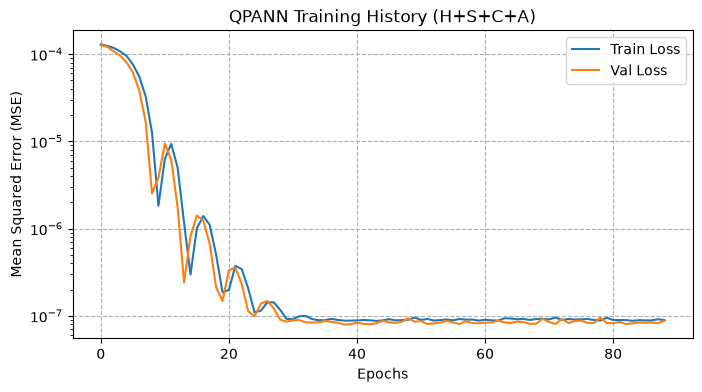

In [19]:
import matplotlib.pyplot as plt

# 1. Encode circuits to tensor
encoder_3q = encoding.StandardCircuitEncoder(pspec_3q)
circuits_tensor_3q = encoding.circuits_to_tensor(circuits_3q, encoder_3q)

# 2. Build snipper. `pspec_3q` already declares 'Gcphase' on our ring connectivity
# (availability['Gcphase']), so we can pass it directly as the qubit graph -- its
# 2-qubit-gate connectivity (pspec_3q.compute_2Q_connectivity()) is used automatically.
# A networkx/igraph/graph-tool graph or a raw Laplacian/adjacency matrix work identically.
snipper_3q = snippers.layer_snipper_from_qubit_graph(true_error_generators, encoder_3q, pspec_3q, hops=1)

# 3. Build QPANN
model_3q = qpanns.QPANN(encoder_3q.length, true_error_generators, snipper_3q)
x_3q = [circuits_tensor_3q, alphas_3q, probabilities_ideal_3q]

# 4. Compile & Fit
epochs = 400
learning_rate = 2e-3
model_3q.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse', metrics=['R2Score', 'mae'])
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

print("Training QPANN (H+S+C+A)...")
history = model_3q.fit(
    x_3q, exact_probabilities,
    epochs=epochs, batch_size=200, callbacks=[early_stopping], validation_split=0.2, verbose=1
)
print(f"Training finished after {len(history.history['loss'])} epochs!")
print(f"Final Validation R2 Score: {history.history['val_R2Score'][-1]:.5f}")

# 5. Plot training & validation loss curves on log y-scale
plt.figure(figsize=(8, 4))
plt.semilogy(history.history['loss'], label='Train Loss')
plt.semilogy(history.history['val_loss'], label='Val Loss')
plt.title('QPANN Training History (H+S+C+A)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

---
## 4. Extracting and Validating Learned Error Rates

Since our synthetic noisy device has a constant rate per layer, the QPANN's predicted error rates should also converge to be nearly constant across layers and match our injected true rates!

Let's:
1. Extract the predicted rates by passing an all-zero dummy circuit vector through `model_3q.dense_layer()`.
2. Format the error generator labels properly as `Type(P,Q)` for two-Pauli terms.
3. Compare the true vs. learned rates in an informative table including both absolute and relative errors.
4. Plot a side-by-side bar chart showing rate recovery across all four sectors.
5. Check whether the *learned* C/A rates satisfy the CP physicality bound (remember: the QPANN network does not enforce this bound architecturally, making this a great validation check).

Error Generator            |  True Rate | Learned Rate |  Abs Error | Rel Error
---------------------------------------------------------------------------
H(XII)                     |    0.00600 |      0.00537 |    0.00063 |    10.5%
H(IYI)                     |    0.00400 |      0.00358 |    0.00042 |    10.5%
S(XII)                     |    0.00500 |      0.00472 |    0.00028 |     5.5%
S(IYI)                     |    0.00400 |      0.00379 |    0.00021 |     5.1%
S(IIX)                     |    0.00300 |      0.00286 |    0.00014 |     4.5%
C(IYI,XII)                 |    0.00200 |      0.00178 |    0.00022 |    11.1%
A(IYI,XII)                 |    0.00180 |      0.00161 |    0.00019 |    10.7%
C(IIX,IYI)                 |    0.00120 |      0.00107 |    0.00013 |    10.7%
A(IIX,IYI)                 |    0.00100 |      0.00091 |    0.00009 |     9.3%

Learned CP check (Pair 1 - qubits {0,1}): sqrt(c^2 + a^2) = 0.002397 vs. sqrt(s_P * s_Q) = 0.004234
  -> Pair 1 satisfies CP conditi

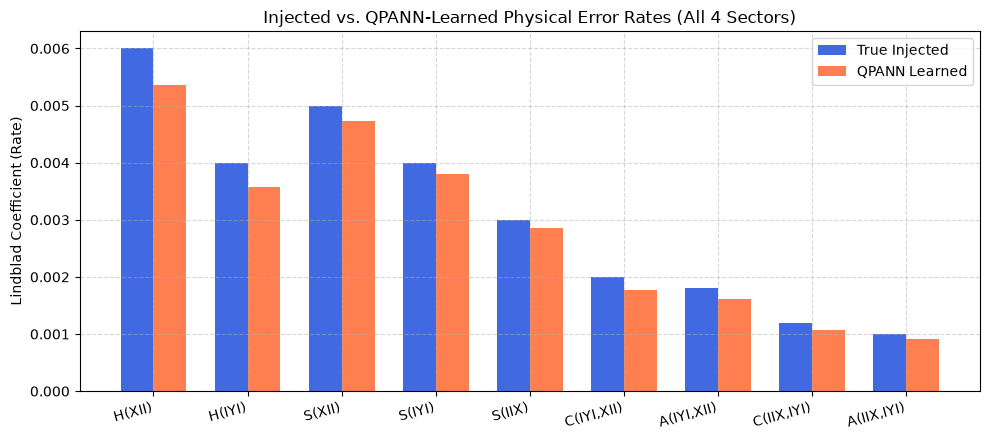

In [20]:
# 1. Call the dense rate-prediction layer on an active gate layer encoding
test_inputs = tf.zeros((1, encoder_3q.length), dtype=tf.float32)
predicted_rates_tensor = model_3q.dense_layer(test_inputs)
learned_rates = tf.squeeze(predicted_rates_tensor).numpy()

print(f"{'Error Generator':<26s} | {'True Rate':>10s} | {'Learned Rate':>12s} | {'Abs Error':>10s} | {'Rel Error':>9s}")
print("-" * 75)
for eg, t_rate, l_rate in zip(true_error_generators, true_rates, learned_rates):
    abs_err = abs(t_rate - l_rate)
    rel_err = abs_err / abs(t_rate)
    lbl = f"{eg[0]}({','.join(eg[1])})"
    print(f"{lbl:<26s} | {t_rate:>10.5f} | {l_rate:>12.5f} | {abs_err:>10.5f} | {rel_err:>8.1%}")

# 2. Check the learned C/A vs S rates CPTPLND physical condition for both pairs
l_s_XII, l_s_IYI, l_s_IIX = learned_rates[2], learned_rates[3], learned_rates[4]
l_c1, l_a1 = learned_rates[5], learned_rates[6]
l_c2, l_a2 = learned_rates[7], learned_rates[8]

print(f"\nLearned CP check (Pair 1 - qubits {{0,1}}): sqrt(c^2 + a^2) = {np.hypot(l_c1, l_a1):.6f} vs. sqrt(s_P * s_Q) = {np.sqrt(l_s_IYI * l_s_XII):.6f}")
if l_c1**2 + l_a1**2 <= l_s_IYI * l_s_XII:
    print("  -> Pair 1 satisfies CP condition.")
else:
    print("  -> Pair 1 violates CP condition (the network does not enforce this).")

print(f"Learned CP check (Pair 2 - qubits {{1,2}}): sqrt(c^2 + a^2) = {np.hypot(l_c2, l_a2):.6f} vs. sqrt(s_P * s_Q) = {np.sqrt(l_s_IYI * l_s_IIX):.6f}")
if l_c2**2 + l_a2**2 <= l_s_IYI * l_s_IIX:
    print("  -> Pair 2 satisfies CP condition.")
else:
    print("  -> Pair 2 violates CP condition (the network does not enforce this).")

# 3. Plot comparison bar chart
fig, ax = plt.subplots(figsize=(10, 4.5))
x_indices = np.arange(len(true_error_generators))
bar_width = 0.35

ax.bar(x_indices - bar_width/2, true_rates, bar_width, label='True Injected', color='royalblue')
ax.bar(x_indices + bar_width/2, learned_rates, bar_width, label='QPANN Learned', color='coral')

ax.set_title('Injected vs. QPANN-Learned Physical Error Rates (All 4 Sectors)')
ax.set_xticks(x_indices)
ax.set_xticklabels([f"{eg[0]}({','.join(eg[1])})" for eg in true_error_generators], rotation=15, ha='right')
ax.set_ylabel('Lindblad Coefficient (Rate)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary and Next Steps

Congratulations! You have successfully built, simulated, trained, and characterized a quantum device using a **Quantum Physics-Aware Neural Network (QPANN)** across all four sectors of the small error taxonomy: Hamiltonian, Stochastic, Pauli-Correlation, and Active.

### Key Takeaways:
* **Rate Recovery:** The QPANN was only given access to *circuits* and *measured outcome probabilities*. Yet, by utilizing efficient Clifford error propagation, it successfully extracted both coherent single-qubit errors and two-qubit correlated/active crosstalk.
* **Limitations:** 
  * **First-Order Bounds:** A QPANN relies on a first-order Taylor approximation. When physical error rates grow large, second-and-higher-order BCH terms emerge, and the linear approximation quality degrades.
  * **Physicality Bounds:** While the physical simulator strictly enforces positive-semidefiniteness ($c^2 + a^2 \le s_P s_Q$) during data generation, the QPANN's unconstrained output layer does not enforce this bound.
* **Interpretation:** The QPANN's learned rates represent concrete, physically rigorous Lindblad error coefficients on the active qubits—providing a highly interpretable alternative to black-box models.

### Further Reading:
* Review the original [NeurIPS 2024 paper](https://arxiv.org/abs/2406.05636) for detailed benchmarks and high-qubit-count simulations.
* Explore the other parts of this series for deeper looks at [bookkeeping/encoding](QPANN-CircuitEncoding.ipynb) and [propagation/locality](QPANN-ErrorPropagation.ipynb).